In [1]:
from shapely.geometry import Point, Polygon

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [2]:
c = np.load("/home/esraan/CellDeathSpreading/results/sliding_time_window_10/nuc_0.005_prop_0.2.csv_factor_of_change_map_5_tods_5.npy")

In [3]:
c

array([[1.48233127, 1.48081931, 1.47700693, 1.36869232, 1.35348536],
       [1.23496456, 1.25631186, 1.17219018, 1.09052542, 1.05858339],
       [1.11203764, 1.06485338, 1.05463437, 1.04394116, 1.03239298],
       [1.03572993, 1.02132755, 1.0165232 , 1.00995241, 1.00534992],
       [1.00936523, 1.00583548, 1.00253504, 1.000896  , 1.00037933]])

In [13]:
#intialization of parameters
dir_path_to_save_nrf_plots = "/home/esraan/CellDeathSpreading/results/sliding_time_window_10/"
meta_data_full_file_path=  "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/file_info.csv"

#start aggregation of NRF-data
def draw_NRF_mean_std (files_to_NRF_aggregate:list,dir_path_to_save_nrf_plots:str,cell_line_analyze:str,treatment_to_analyze:str,  **kwargs)->None:
    cbarlabel = kwargs.get('cbarlabel', 'factor of non randomly')
    from matplotlib.pyplot import figure

    figure(figsize=(8, 6), dpi=200)
    max_number_of_dead_neighbors_to_calc=kwargs.get("max_number_of_dead_neighbors_to_calc",5)
    max_delta_tod_from_recently_dead_neighbor = kwargs.get("max_delta_tod_from_recently_dead_neighbor",5)
    number_of_random_permutations = kwargs.get('number_of_random_permutations', 1000)
    cbar_kwargs = kwargs.get('cbar_kwargs', {})
    scale_limit = kwargs.get('vmax',5.)
    list_for_treatment_cell_line = []
    for nrf_exp_file in files_to_NRF_aggregate["File_name"]:
        print(nrf_exp_file)
        full_path_to_npy_exp_file = os.path.join(dir_path_to_save_nrf_plots, nrf_exp_file)
        np_array_result = np.load(full_path_to_npy_exp_file)
        list_for_treatment_cell_line.append(np_array_result)
        # np_array_result = np.flip(np.load(full_path_to_npy_exp_file),axis=0)
        
    stacked_array = np.stack(list_for_treatment_cell_line, axis=0)
    stacked_array_mean = np.flip(stacked_array.mean(axis=0),axis=0)
    stacked_array_std = np.flip(stacked_array.std(axis=0),axis=0)
    plt.clf()
    fig, ax = plt.subplots()
    fig_title = kwargs.get('fig_title',
                            f'Non Randomality Factor Results\n'
                            f'{cell_line_analyze+" + "+treatment_to_analyze}\n#Permutations:{number_of_random_permutations}')
    im = ax.imshow(stacked_array_mean, cmap="YlGn", vmin=kwargs.get('fig_v_min', 1.), vmax=kwargs.get('fig_v_max', scale_limit))
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kwargs)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")
    num_neighbors_to_calc = np.arange(0, max_number_of_dead_neighbors_to_calc, 1)
    delta_in_tod_to_calc = np.arange(0, max_delta_tod_from_recently_dead_neighbor, 1)
    ax.set_xticks(num_neighbors_to_calc)
    ax.set_yticks(delta_in_tod_to_calc)
    ax.set_xticklabels([f"{n+1}" for n in num_neighbors_to_calc])
    ax.set_xlabel('number of dead neighbors at death time-1')
    exp_treatment, temporal_multiplier = get_exp_treatment_type_and_temporal_resolution(exp_file_name=nrf_exp_file.split(".csv")[0]+".csv",
                                                                                            meta_data_file_full_path=meta_data_full_file_path)

    med_list_ylabel = [f"{(t+1)*30}" for t in delta_in_tod_to_calc] # change according to TOD's
    med_list_ylabel.reverse()
    ax.set_yticklabels(med_list_ylabel)
    ax.set_ylabel('death time difference')
    ax.set_title(fig_title)
    for i in num_neighbors_to_calc:
        for j in delta_in_tod_to_calc:
            mean_val= round(stacked_array_mean[i, j],2)
            std_val = round(stacked_array_std[i, j],2)
            ax.text(j, i, f"{mean_val}",
                            ha="center", va="center", color="black",fontsize=7)
            # ax.text(j, i, f"{mean_val}±{std_val}",
            #                 ha="center", va="center", color="black",fontsize=7)
    exp_treatment = exp_treatment.replace(os.sep, '_')
    if kwargs.get("dir_path_to_save_nrf_plots", None) is not None:
        dir_path_to_save = os.path.join(kwargs.get("dir_path_to_save_nrf_plots"), f'HigherScale{kwargs.get("fig_v_min", 1):.1f}_{kwargs.get("fig_v_max", 5.):.1f}', f'{exp_treatment}')
    else:
        dir_path_to_save = os.path.join('..','Results','NonRandomalityFactorResults', f'HigherScale{kwargs.get("fig_v_min", 1):.1f}_{kwargs.get("fig_v_max", 5.):.1f}', f'{exp_treatment}')

    if kwargs.get('save_fig', False):
        exp_name = nrf_exp_file.split(".csv")[0]+".csv"
        os.makedirs(dir_path_to_save, exist_ok=True)
        fig_path_png = os.path.join(dir_path_to_save, f"{exp_name}.png")
        fig_path_eps = os.path.join(dir_path_to_save, f"{exp_name}.eps")
        plt.savefig(fig_path_eps, dpi=300)
        print(fig_path_png)
        plt.savefig(fig_path_png, dpi=600)
    plt.show()
        

In [14]:
#OLD DATA
exps_dir_name = "/home/esraan/CellDeathSpreading/results/sliding_time_window_10/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/file_info.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:96,0]

def organize_list_of_nrf_files_names(dir, str_files_endswith_toremove = "neighbors_5_tods_5.npy",
                                     **kwargs)->list:
    list_of_files_in_dir = os.listdir(dir)
    idx=0
    files_number_to_iterate_over = len(list_of_files_in_dir)
    while idx <files_number_to_iterate_over:
        path = os.path.join(dir, list_of_files_in_dir[idx])
        if os.path.isdir(path):
        # skip directories
            del list_of_files_in_dir[idx]
            idx -=1
        if list_of_files_in_dir[idx].endswith(str_files_endswith_toremove) or list_of_files_in_dir[idx].endswith("DS_Store"):
            del list_of_files_in_dir[idx]
            idx -=1
        files_number_to_iterate_over = len(list_of_files_in_dir)
        idx +=1
    return list_of_files_in_dir
dir_str = '/home/esraan/CellDeathSpreading/results/sliding_time_window_10/'
exp_nrf_npys_names = organize_list_of_nrf_files_names(dir=dir_str)


In [15]:
exp_nrf_npys_names = pd.DataFrame(exp_nrf_npys_names, columns=["File_name"])

In [16]:
exp_nrf_npys_names

,File_name
0,nuc_0.005_prop_0.2.csv_factor_of_change_map_5_...


nuc_0.005_prop_0.2.csv_factor_of_change_map_5_tods_5.npy
../Results/NonRandomalityFactorResults/HigherScale1.0_5.0/nuc=0.005,prop=0.2/nuc_0.005_prop_0.2.csv.png


<Figure size 1600x1200 with 0 Axes>

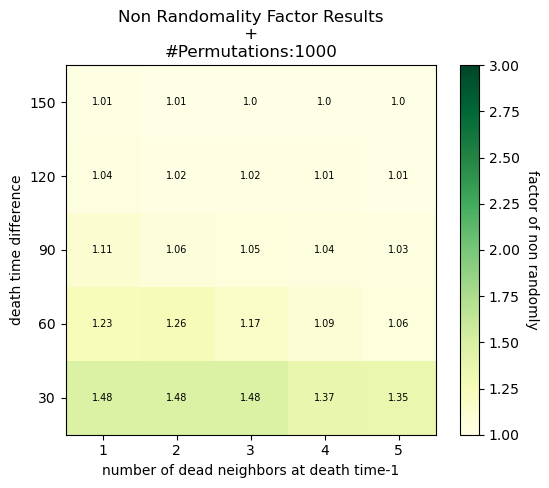

In [17]:

draw_NRF_mean_std(exp_nrf_npys_names,dir_path_to_save_nrf_plots,treatment_to_analyze="",exp_to_analyze="",vmax = 3, save_fig=True, cell_line_analyze="")